# Agent graph

The LangGraph agent drawn from its own wiring in `rag_sql.agent.graph.build_graph()`, so the picture always matches the code.

- Solid arrows always run in order: `load_history` → … → `generate_sql` → `validate_sql`.
- Dotted arrows are the conditional routes: `validate_sql` and `execute_sql` go back to `generate_sql` on an error (up to `MAX_SQL_RETRIES` times), otherwise on to `execute_sql` / `answer`.

Nothing here needs Postgres or Ollama.

In [1]:
from unittest.mock import Mock

from IPython.display import Image, display

from rag_sql.agent.graph import build_graph

# Drawing only needs the wiring, so placeholders stand in for the model, retriever and stores and
# nothing connects to Postgres or Ollama. build_graph() with no arguments draws the same graph.
graph = build_graph(
    llm=Mock(), retriever=Mock(), query_runner=Mock(), chat_store=Mock(), query_history=Mock()
)
drawable = graph.get_graph()
mermaid = drawable.draw_mermaid()

## Diagram

JupyterLab (4.1+) draws Mermaid itself, offline. Other frontends (e.g. VS Code) show the Mermaid text instead; use the PNG below there.

In [2]:
display({"text/vnd.mermaid": mermaid, "text/plain": mermaid}, raw=True)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	load_history(load_history)
	condense_question(condense_question)
	retrieve_context(retrieve_context)
	find_similar_queries(find_similar_queries)
	generate_sql(generate_sql)
	validate_sql(validate_sql)
	execute_sql(execute_sql)
	answer(answer)
	save_turn(save_turn)
	save_query_example(save_query_example)
	__end__([<p>__end__</p>]):::last
	__start__ --> load_history;
	answer --> save_turn;
	condense_question --> retrieve_context;
	execute_sql -.-> answer;
	execute_sql -.-> generate_sql;
	find_similar_queries --> generate_sql;
	generate_sql --> validate_sql;
	load_history --> condense_question;
	retrieve_context --> find_similar_queries;
	save_turn --> save_query_example;
	validate_sql -.-> answer;
	validate_sql -.-> execute_sql;
	validate_sql -.-> generate_sql;
	save_query_example --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#b

## As a PNG

Works in any notebook frontend. `draw_mermaid_png()` renders through the mermaid.ink web service, so it needs internet access; it only sends the node and edge names.

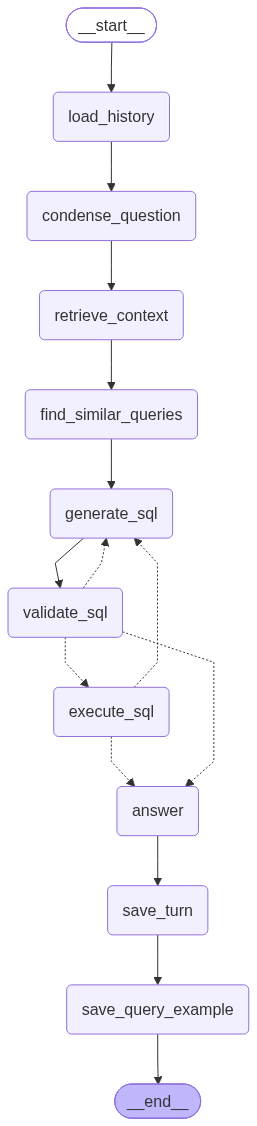

In [3]:
png = drawable.draw_mermaid_png()
display(Image(png))
# To save it: Path("agent_graph.png").write_bytes(png)  (from pathlib import Path)

## Mermaid source

Paste into a `mermaid` code block in Markdown (GitHub and VS Code render it) or into https://mermaid.live.

In [4]:
print(mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	load_history(load_history)
	condense_question(condense_question)
	retrieve_context(retrieve_context)
	find_similar_queries(find_similar_queries)
	generate_sql(generate_sql)
	validate_sql(validate_sql)
	execute_sql(execute_sql)
	answer(answer)
	save_turn(save_turn)
	save_query_example(save_query_example)
	__end__([<p>__end__</p>]):::last
	__start__ --> load_history;
	answer --> save_turn;
	condense_question --> retrieve_context;
	execute_sql -.-> answer;
	execute_sql -.-> generate_sql;
	find_similar_queries --> generate_sql;
	generate_sql --> validate_sql;
	load_history --> condense_question;
	retrieve_context --> find_similar_queries;
	save_turn --> save_query_example;
	validate_sql -.-> answer;
	validate_sql -.-> execute_sql;
	validate_sql -.-> generate_sql;
	save_query_example --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#b